moyenne des pentes : 0.3498
écart-type : 0.0259


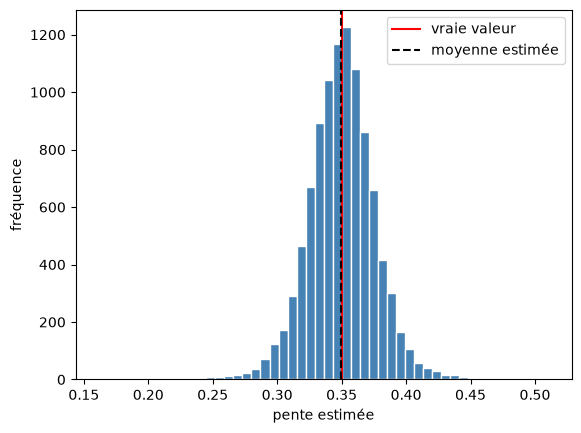

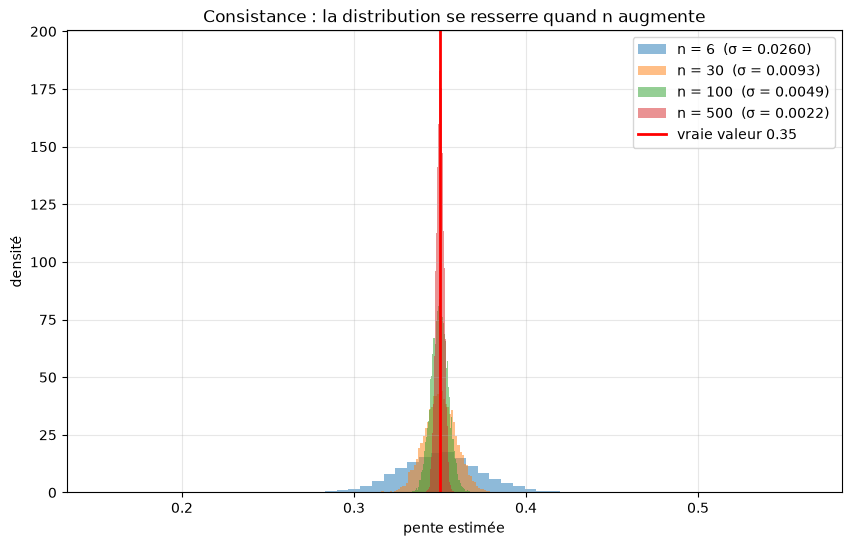

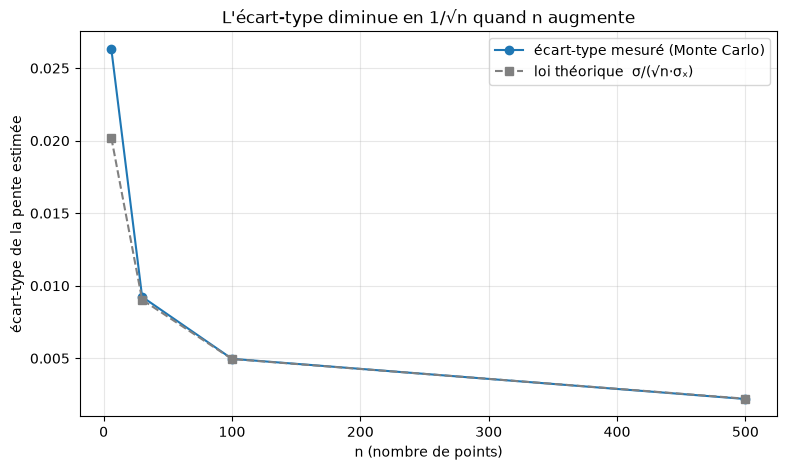

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def simuler_pente(n, pente_vraie=0.35, sigma=0.002):
    x = rng.uniform(0.01, 0.15, n)  # on genere n points au hasard 
    y = pente_vraie * x + rng.normal(0, sigma, n)         # vraie droite + bruit
    return np.mean((x - x.mean()) * (y - y.mean())) / np.mean((x - x.mean())**2)    # meilleure pente

# Monte Carlo : on répète l'expérience 10 000 fois
pentes = np.array([simuler_pente(6) for _ in range(10_000)])
print(f"moyenne des pentes : {pentes.mean():.4f}")
print(f"écart-type : {pentes.std():.4f}")

# Sans biais : la moyenne tombe sur 0.35
plt.hist(pentes, bins=50, color="steelblue", edgecolor="white")
plt.axvline(0.35, color="red", label="vraie valeur")
plt.axvline(pentes.mean(), color="black", ls="--", label="moyenne estimée")
plt.legend(); plt.xlabel("pente estimée"); plt.ylabel("fréquence"); plt.show()

# Consistance : l'écart-type diminue quand n augmente
tailles = [6, 30, 100, 500]
K = 10_000

plt.figure(figsize=(10, 6))
for n in tailles:
    pentes = np.array([simuler_pente(n) for _ in range(K)])
    plt.hist(pentes, bins=60, alpha=0.5, density=True, label=f"n = {n}  (σ = {pentes.std():.4f})")  

plt.axvline(0.35, color="red", lw=2, label="vraie valeur 0.35")
plt.xlabel("pente estimée")
plt.ylabel("densité")
plt.title("Consistance : la distribution se resserre quand n augmente")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calcul de l'écart type réel vs théorique en fonction de n
ns = np.array([6, 30, 100, 500])

sigma_reel = []
for n in ns:
    pentes = np.array([simuler_pente(n) for i in range(K)])
    sigma_reel.append(pentes.std())

# loi en 1/√n
ecart_type = (0.15 - 0.01) / np.sqrt(12)              
sigma_theorique = 0.002 / (np.sqrt(ns) * ecart_type)   

plt.figure(figsize=(9, 5))
plt.plot(ns, sigma_reel, "o-", label="écart-type mesuré (Monte Carlo)")
plt.plot(ns, sigma_theorique, "s--", color="gray", label="loi théorique  σ/(√n·σₓ)")
plt.xlabel("n (nombre de points)")
plt.ylabel("écart-type de la pente estimée")
plt.title("L'écart-type diminue en 1/√n quand n augmente")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()